In [25]:
import argparse
import pickle
 
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import cmocean as cmc
from matplotlib.colors import ListedColormap

plt.style.use("../plotstyling.mplstyle")

In [56]:
date_str = "2025-07_to_2026-06"

with open(f"../data/aws_fwp_band_0.002_0.003_cases_{date_str}_v3.pkl", "rb") as f:
    cases = pickle.load(f)


In [57]:
fwp_min = cases["config"]["fwp_min"]
fwp_max = cases["config"]["fwp_max"]

low = cases["ea_iwp_closest"] < 1e-2        # EarthCARE saw little or no ice
high = cases["ea_iwp_closest"] >= 1e-1


In [58]:
print(f"{len(cases['time'])} cases, AWS FWP from {cases['config']['fwp_min']:g} "
      f"to {cases['config']['fwp_max']:g} kg m-2")
 
# unique dates, with the number of cases on each
dates = pd.DatetimeIndex(cases["time"]).normalize()
counts = dates.value_counts().sort_index()
 
print(f"\n{len(counts)} unique dates:")
for date, n in counts.items():
    print(f"  {date:%Y-%m-%d}: {n}")


128 cases, AWS FWP from 0.002 to 0.003 kg m-2

4 unique dates:
  2025-08-05: 53
  2025-08-06: 26
  2026-01-01: 23
  2026-06-01: 26


Text(0.5, 1.0, 'Cases with 0.002 <= AWS FWP < 0.003 kg m$^{-2}$ (n=128)')

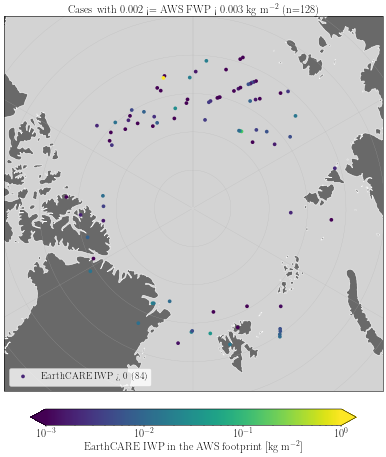

In [59]:
lat = cases["lat"]
lon = cases["lon"]
ea_iwp = cases["ea_iwp_closest"]
clear = ea_iwp <= 0          # EarthCARE saw no ice: cannot go on a log colour scale
 
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(projection=ccrs.NorthPolarStereo())
ax.set_extent([-180, 180, 75, 90], crs=ccrs.PlateCarree())
 
ax.add_feature(cfeature.OCEAN.with_scale("50m"), facecolor="lightgrey", zorder=0)
ax.add_feature(cfeature.LAND.with_scale("50m"), facecolor="dimgrey", zorder=0)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), edgecolor="white", linewidth=0.5, zorder=1)
ax.coastlines(color="white", linewidth=1, zorder=1)
ax.gridlines(draw_labels=False, linewidth=0.3)
 
#ax.scatter(lon[clear], lat[clear], s=12, color="black", ec="none",
#           transform=ccrs.PlateCarree(), zorder=2,
#           label=f"EarthCARE IWP = 0 ({clear.sum()})")
sc = ax.scatter(lon[~clear], lat[~clear], c=ea_iwp[~clear], s=45, ec="none",
                norm=LogNorm(vmin=1e-3, vmax=1e0), cmap="viridis",
                transform=ccrs.PlateCarree(), zorder=3,
                label=f"EarthCARE IWP > 0 ({(~clear).sum()})")
 
fig.colorbar(sc, ax=ax, orientation="horizontal", shrink=0.7, pad=0.04, extend="both",
             label=r"EarthCARE IWP in the AWS footprint [kg m$^{-2}$]")
ax.legend(loc="lower left")
ax.set_title(f"Cases with {fwp_min:g} <= AWS FWP < {fwp_max:g} kg m$^{{-2}}$ "
             f"(n={len(lat)})")
 
#fig_path = Path(args.fig_dir) / f"{Path(args.cases_file).stem}_map.png"
#fig.savefig(fig_path, dpi=200, bbox_inches="tight", facecolor="white")


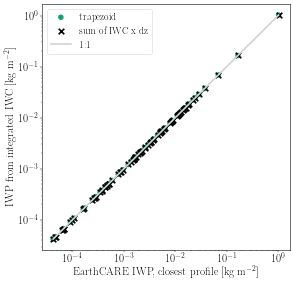

In [60]:
fig, ax = plt.subplots(figsize=(8, 8))

iwc = np.nan_to_num(cases["ea_iwc"], nan=0.0)                 # missing IWC counts as no ice
iwc_integral = np.abs(np.trapezoid(iwc, x=cases["ea_height"], axis=1))

dz = np.abs(np.gradient(cases["ea_height"], axis=1))
iwp_from_iwc = np.nansum(cases["ea_iwc"] * dz, axis=1)

ax.scatter(cases["ea_iwp_closest"], iwc_integral, label="trapezoid")
ax.scatter(cases["ea_iwp_closest"], iwp_from_iwc, marker="x", c="k", label="sum of IWC x dz")

lims = [np.nanmin(cases["ea_iwp_closest"][cases["ea_iwp_closest"] > 0]),
        np.nanmax(cases["ea_iwp_closest"])]
ax.plot(lims, lims, c="lightgrey", label="1:1")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"EarthCARE IWP, closest profile [kg m$^{-2}$]")
ax.set_ylabel(r"IWP from integrated IWC [kg m$^{-2}$]")
ax.legend()


fraction of cases per surface type (EarthCARE IWP < 1e-2, >= 1e-2):
     ocean:  0.110  0.000
    seaice:  0.275  0.000
      land:  0.018  0.000
     water:  0.000  0.000
      snow:  0.248  1.000
   glacier:  0.009  0.000
     mixed:  0.339  0.000
   missing:  0.000  0.000


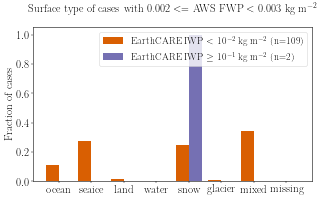

In [61]:
# ============================================================
# SURFACE TYPES
# ============================================================
surface_types = cases["surface_types"]
frac = cases["aws_surface_fractions"]          # (case, surface type)

# a case is the surface with the largest fraction if that fraction is above 0.8,
# otherwise "mixed"; cases with no valid fractions are "missing"
has_frac = np.isfinite(frac).any(axis=1)
frac_filled = np.where(np.isfinite(frac), frac, -1.0)
largest = frac_filled.argmax(axis=1)
largest_frac = frac_filled.max(axis=1)

surface_class = np.where(largest_frac > 0.9,
                         np.array(surface_types)[largest], "mixed")
surface_class[~has_frac] = "missing"

classes = list(surface_types) + ["mixed", "missing"]

counts_low = np.array([np.sum((surface_class == c) & low) for c in classes])
counts_high = np.array([np.sum((surface_class == c) & high) for c in classes])

# each colour sums to 1 over the surface types
frac_low = counts_low / counts_low.sum()
frac_high = counts_high / counts_high.sum()

print("\nfraction of cases per surface type (EarthCARE IWP < 1e-2, >= 1e-2):")
for c, f_low, f_high in zip(classes, frac_low, frac_high):
    print(f"  {c:>8s}: {f_low:6.3f} {f_high:6.3f}")

x = np.arange(len(classes))
width = 0.4

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width / 2, frac_low, width, color="C1",
       label=rf"EarthCARE IWP $<$ 10$^{{-2}}$ kg m$^{{-2}}$ (n={counts_low.sum()})")
ax.bar(x + width / 2, frac_high, width, color="C2",
       label=rf"EarthCARE IWP $\geq$ 10$^{{-1}}$ kg m$^{{-2}}$ (n={counts_high.sum()})")


ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylabel("Fraction of cases")
ax.set_title(f"Surface type of cases with {fwp_min:g} $<=$ AWS FWP $<$ {fwp_max:g} kg m$^{{-2}}$\n")
ax.legend()

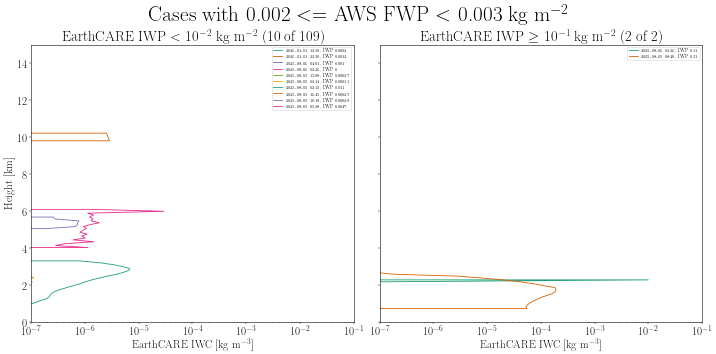

In [62]:
rng = np.random.default_rng(0)   # fixed seed, so the same cases are drawn each time

fig, axes = plt.subplots(1, 2, figsize=(18, 9), sharey=True)

for ax, group, title in [
    (axes[0], low, r"EarthCARE IWP $<$ 10$^{-2}$ kg m$^{-2}$"),
    (axes[1], high, r"EarthCARE IWP $\geq$ 10$^{-1}$ kg m$^{-2}$"),
]:
    idx = np.flatnonzero(group)
    chosen = rng.choice(idx, size=min(10, idx.size), replace=False)

    for i in chosen:
        label = f"{pd.Timestamp(cases['time'][i]):%Y-%m-%d %H:%M}, IWP {cases['ea_iwp'][i]:.2g}"
        ax.plot(cases["ea_iwc"][i], cases["ea_height"][i] / 1000, lw=1.5, label=label)

    ax.set_xscale("log")
    ax.set_xlim(1e-7, 1e-1)
    ax.set_xlabel(r"EarthCARE IWC [kg m$^{-3}$]")
    ax.set_title(f"{title} ({chosen.size} of {idx.size})", fontsize=26)
    ax.legend(fontsize=8, loc="upper right")

axes[0].set_ylim(0, 15)
axes[0].set_ylabel("Height [km]")
fig.suptitle(f"Cases with {fwp_min:g} $<=$ AWS FWP $<$ {fwp_max:g} kg m$^{{-2}}$")
fig.tight_layout()
plt.show()

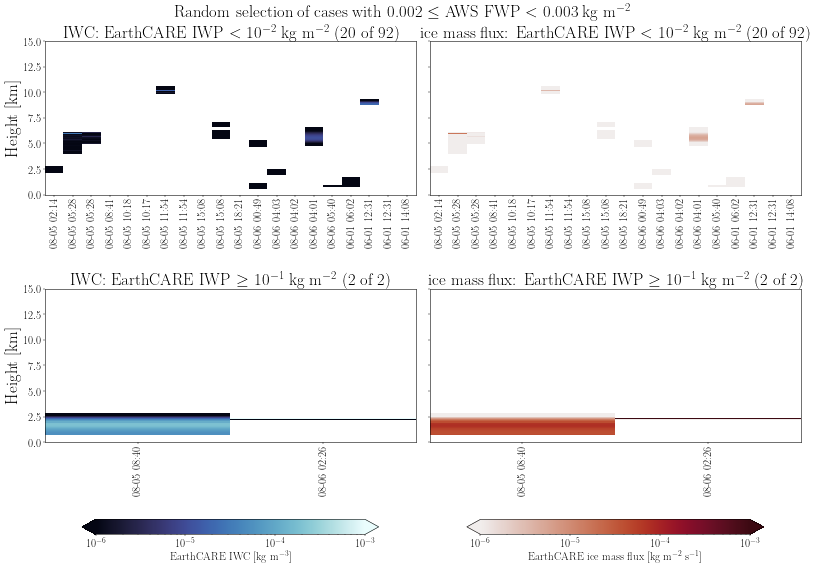

In [55]:

rng = np.random.default_rng(2)   # fixed seed, so the same cases are drawn each time

fig, axes = plt.subplots(2, 2, figsize=(20, 14), sharey=True, layout="constrained")

for row, group, title in [
    (0, low, r"EarthCARE IWP $<$ 10$^{-2}$ kg m$^{-2}$"),
    (1, high, r"EarthCARE IWP $\geq$ 10$^{-1}$ kg m$^{-2}$"),
]:
    idx = np.flatnonzero(group)
    chosen = np.sort(rng.choice(idx, size=min(20, idx.size), replace=False))

    iwc = cases["ea_iwc"][chosen]                   # (case, level)
    flux = cases["ea_ice_mass_flux"][chosen]        # (case, level)
    height = cases["ea_height"][chosen] / 1e3       # (case, level), km
    x_2d = np.broadcast_to(np.arange(chosen.size)[:, None], iwc.shape)

    # left: ice water content
    pm_iwc = axes[row, 0].pcolormesh(x_2d.T, height.T, iwc.T,
                                     shading="nearest", norm=LogNorm(vmin=1e-6, vmax=1e-3),
                                     cmap=cmc.cm.ice)
    # right: ice mass flux, for the same cases
    pm_flux = axes[row, 1].pcolormesh(x_2d.T, height.T, flux.T,
                                      shading="nearest", norm=LogNorm(vmin=1e-6, vmax=1e-3),
                                      cmap=cmc.cm.amp)

    # label each column with the case's time, in both panels
    time_labels = [f"{pd.Timestamp(cases['time'][i]):%m-%d %H:%M}" for i in chosen]
    for col, name in [(0, "IWC"), (1, "ice mass flux")]:
        ax = axes[row, col]
        ax.set_xticks(np.arange(chosen.size))
        ax.set_xticklabels(time_labels, rotation=90, fontsize=20)
        ax.set_title(f"{name}: {title} ({chosen.size} of {idx.size})", fontsize=30)

axes[0, 0].set_ylim(0, 15)
axes[0, 0].set_ylabel("Height [km]", fontsize=30)
axes[1, 0].set_ylabel("Height [km]", fontsize=30)

# one colour bar under each column
fig.colorbar(pm_iwc, ax=axes[:, 0], orientation="horizontal", extend="both", shrink=0.8,
             label=r"EarthCARE IWC [kg m$^{-3}$]")
fig.colorbar(pm_flux, ax=axes[:, 1], orientation="horizontal", extend="both", shrink=0.8,
             label=r"EarthCARE ice mass flux [kg m$^{-2}$ s$^{-1}$]")

fig.suptitle(f"Random selection of cases with {fwp_min:g} $\\leq$ AWS FWP $<$ {fwp_max:g} kg m$^{{-2}}$",
             fontsize=30)

# space between the panels, as a fraction of the figure size
fig.get_layout_engine().set(hspace=0.08, wspace=0.03)

plt.savefig("../figures/aws_band/random_profiles.png",
            facecolor="white", bbox_inches="tight", dpi=200)

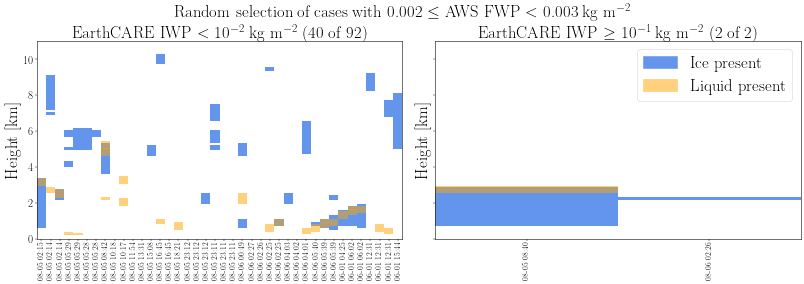

In [52]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True, layout="constrained")

for ax, group, title in [
    (axes[0], low, r"EarthCARE IWP $<$ 10$^{-2}$ kg m$^{-2}$"),
    (axes[1], high, r"EarthCARE IWP $\geq$ 10$^{-1}$ kg m$^{-2}$"),
]:
    idx = np.flatnonzero(group)
    chosen = np.sort(rng.choice(idx, size=min(40, idx.size), replace=False))

    iwc = cases["ea_iwc"][chosen]                   # (case, level)
    lwc = cases["ea_lwc"][chosen]                   # (case, level)
    rwc = cases["ea_rwc"][chosen]                   # (case, level)
    ice_flux = cases["ea_ice_mass_flux"][chosen]    # (case, level)

    height = cases["ea_height"][chosen] / 1e3       # (case, level), km
    x_2d = np.broadcast_to(np.arange(chosen.size)[:, None], iwc.shape)

    has_ice = np.where(iwc > 0, 1.0, np.nan)        # 1 where there is ice, blank elsewhere
    ax.pcolormesh(x_2d.T, height.T, has_ice.T,
                  shading="nearest", cmap=ListedColormap(["cornflowerblue"]))

    has_liquid = np.where(lwc > 0, 1.0, np.nan)     # 1 where there is liquid, blank elsewhere
    ax.pcolormesh(x_2d.T, height.T, has_liquid.T,
                  shading="nearest", cmap=ListedColormap(["orange"]), alpha=0.5)

    has_rain = np.where(rwc > 0, 1.0, np.nan)       # 1 where there is rain, blank elsewhere
    #ax.pcolormesh(x_2d.T, height.T, has_rain.T,
    #              shading="nearest", cmap=ListedColormap(["cornflowerblue"]), alpha=0.5)

    # label each column with the case's time
    ax.set_xticks(np.arange(chosen.size))
    ax.set_xticklabels([f"{pd.Timestamp(cases['time'][i]):%m-%d %H:%M}" for i in chosen],
                       rotation=90, fontsize=14)
    ax.set_title(f"{title} ({chosen.size} of {idx.size})", fontsize=30)

axes[0].set_ylim(0, 11)
axes[0].set_ylabel("Height [km]", fontsize=30)
axes[1].set_ylabel("Height [km]", fontsize=30)

# legend instead of a colour bar
legend_handles = [
    Patch(color="cornflowerblue", label="Ice present"),
    Patch(color="orange", alpha=0.5, label="Liquid present"),
]
axes[1].legend(handles=legend_handles, loc="upper right", fontsize=30)

fig.suptitle(f"Random selection of cases with {fwp_min:g} $\\leq$ AWS FWP $<$ {fwp_max:g} kg m$^{{-2}}$",
             fontsize=30)

# space between the panels, as a fraction of the figure width
fig.get_layout_engine().set(wspace=0.03)

plt.savefig("../figures/aws_band/random_profiles_with_lwc.png",
            facecolor="white", bbox_inches="tight", dpi=200)

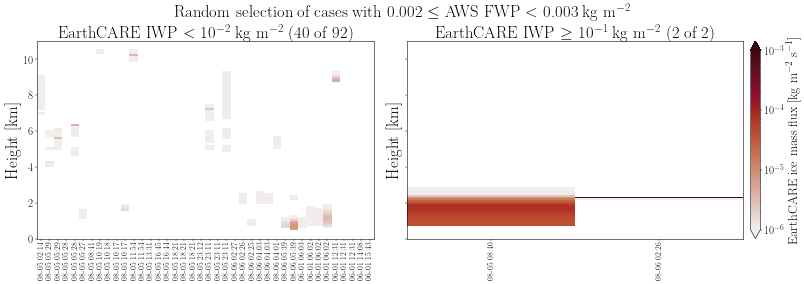

In [54]:
rng = np.random.default_rng(2)   # fixed seed, so the same cases are drawn each time

fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True, layout="constrained")

for ax, group, title in [
    (axes[0], low, r"EarthCARE IWP $<$ 10$^{-2}$ kg m$^{-2}$"),
    (axes[1], high, r"EarthCARE IWP $\geq$ 10$^{-1}$ kg m$^{-2}$"),
]:
    idx = np.flatnonzero(group)
    chosen = np.sort(rng.choice(idx, size=min(40, idx.size), replace=False))

    flux = cases["ea_ice_mass_flux"][chosen]        # (case, level)
    height = cases["ea_height"][chosen] / 1e3       # (case, level), km
    x_2d = np.broadcast_to(np.arange(chosen.size)[:, None], flux.shape)

    pm = ax.pcolormesh(x_2d.T, height.T, flux.T,
                       shading="nearest", norm=LogNorm(vmin=1e-6, vmax=1e-3),
                       cmap=cmc.cm.amp)

    # label each column with the case's time
    ax.set_xticks(np.arange(chosen.size))
    ax.set_xticklabels([f"{pd.Timestamp(cases['time'][i]):%m-%d %H:%M}" for i in chosen],
                       rotation=90, fontsize=14)
    ax.set_title(f"{title} ({chosen.size} of {idx.size})", fontsize=30)

axes[0].set_ylim(0, 11)
axes[0].set_ylabel("Height [km]", fontsize=30)
axes[1].set_ylabel("Height [km]", fontsize=30)

# one colour bar for both panels, since they share the colour scale
cbar = fig.colorbar(pm, ax=axes, orientation="vertical", extend="both", pad=0.01)
cbar.set_label(r"EarthCARE ice mass flux [kg m$^{-2}$ s$^{-1}$]", fontsize=24)

fig.suptitle(f"Random selection of cases with {fwp_min:g} $\\leq$ AWS FWP $<$ {fwp_max:g} kg m$^{{-2}}$",
             fontsize=30)

# space between the panels, as a fraction of the figure width
fig.get_layout_engine().set(wspace=0.03)

plt.savefig("../figures/aws_band/random_profiles_flux.png",
            facecolor="white", bbox_inches="tight", dpi=200)

In [13]:
np.max(ice_flux)

np.float32(0.13230912)